In [ ]:
### Cell 1: Install Dependencies

# If not installed, uncomment:
#!pip install torch torchvision  # if you need GPU builds, please see PyTorch website
#!pip install transformers datasets
#!pip install scikit-learn

In [1]:
# Cell 2: Imports and Basic Setup

import math
import numpy as np
import torch
import torch.nn as nn
import requests  # only if you want direct download from e.g. Hugging Face
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# HF Transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

# HuggingFace 'datasets' for The Pile
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Cell 3: Helper function: get_model_name(suite, size, deduped)
def get_model_name(suite, size, deduped=False):
    """
    Return the HF model name for pythia or GPT-Neo, with deduped if relevant.
    """
    suite = suite.lower()
    size = size.lower()
    if suite == "pythia":
        # e.g. pythia-70m or pythia-70m-deduped
        if size == "70m":
            return f"EleutherAI/pythia-70m{'-deduped' if deduped else ''}"
        elif size=="160m":
            return f"EleutherAI/pythia-160m{'-deduped' if deduped else ''}"
        elif size=="1.4b":
            return f"EleutherAI/pythia-1.4b{'-deduped' if deduped else ''}"
        elif size=="2.8b":
            return f"EleutherAI/pythia-2.8b{'-deduped' if deduped else ''}"
        elif size=="6.9b":
            return f"EleutherAI/pythia-6.9b{'-deduped' if deduped else ''}"
        elif size=="12b":
            return f"EleutherAI/pythia-12b{'-deduped' if deduped else ''}"
        else:
            raise ValueError(f"Unsupported pythia size: {size}")
    elif suite=="gpt-neo":
        if size=="125m":
            return "EleutherAI/gpt-neo-125M"
        elif size=="1.3b":
            return "EleutherAI/gpt-neo-1.3B"
        elif size=="2.7b":
            return "EleutherAI/gpt-neo-2.7B"
        else:
            raise ValueError(f"Unsupported gpt-neo size: {size}")
    else:
        raise ValueError(f"Unknown suite: {suite}")

In [3]:
# Cell 4: Next-token loss + signals

@torch.no_grad()
def compute_next_token_losses(text, model, tokenizer, device):
    if not text.strip():
        return []
    #OBS har lagt till max length 1024, dubbelkolla så att det inte påverkar jämförbarheten med CAMIA
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=1024)
    input_ids = enc['input_ids'].to(device)
    outputs = model(input_ids, labels=input_ids)
    logits = outputs.logits
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = input_ids[..., 1:].contiguous()

    loss_fct = nn.CrossEntropyLoss(reduction='none')
    losses = loss_fct(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1)
    )
    seq_len = shift_labels.size(-1)
    losses = losses.view(seq_len).tolist()
    return losses

def token_diversity(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    if len(tokens)==0:
        return 0.0
    return len(set(tokens))/len(tokens)

def replicate_if_short(seq, desired_len):
    out = list(seq)
    while len(out)<desired_len:
        out += seq
    return out

def cutoff_loss(loss_seq, Tprime=None):
    if len(loss_seq)==0:
        return float('inf')
    if Tprime is None or Tprime>len(loss_seq):
        return float(np.mean(loss_seq))
    return float(np.mean(loss_seq[:Tprime]))

def slope_signal(loss_seq, Tprime=200):
    seq = replicate_if_short(loss_seq, Tprime) if len(loss_seq)<Tprime else loss_seq
    seq = seq[:Tprime]
    if len(seq)<2:
        return 0.0
    x_vals = np.arange(len(seq))
    y_vals = np.array(seq)
    mean_x = np.mean(x_vals)
    mean_y = np.mean(y_vals)
    numerator   = np.sum((x_vals-mean_x)*(y_vals-mean_y))
    denominator = np.sum((x_vals-mean_x)**2)
    if abs(denominator)<1e-12:
        return 0.0
    return float(numerator/denominator)

def approximate_entropy(loss_seq, Tprime=200, m=8, r=0.8):
    seq = replicate_if_short(loss_seq, Tprime) if len(loss_seq)<Tprime else list(loss_seq)
    seq = seq[:Tprime]
    n = len(seq)
    if n<=m+1:
        return 0.0
    vals = np.array(seq)
    def _maxdist(a,b):
        return np.max(np.abs(a-b))

    x = [vals[i:i+m] for i in range(n-m+1)]
    c = []
    for i in range(len(x)):
        count=0
        for j in range(len(x)):
            if _maxdist(x[i], x[j])<=r:
                count+=1
        c.append(count/len(x))
    phi_m = np.mean(np.log(np.array(c)+1e-9))

    # length m+1
    if n<(m+1)+1:
        return 0.0
    x2 = [vals[i:i+m+1] for i in range(n-(m+1)+1)]
    c2=[]
    for i in range(len(x2)):
        count=0
        for j in range(len(x2)):
            if _maxdist(x2[i], x2[j])<=r:
                count+=1
        c2.append(count/len(x2))
    phi_m2 = np.mean(np.log(np.array(c2)+1e-9))
    return float(phi_m - phi_m2)

def count_below_threshold(loss_seq, threshold, Tprime=200, replicate=False):
    seq = replicate_if_short(loss_seq, Tprime) if replicate else list(loss_seq)
    seq = seq[:Tprime]
    if len(seq)==0:
        return 0.0
    return sum(1 for x in seq if x<=threshold)/len(seq)

def count_below_mean(loss_seq, Tprime=200, replicate=False):
    seq = replicate_if_short(loss_seq, Tprime) if replicate else list(loss_seq)
    seq = seq[:Tprime]
    if len(seq)==0:
        return 0.0
    avg_val = np.mean(seq)
    return sum(1 for x in seq if x<=avg_val)/len(seq)

def count_below_prev_mean(loss_seq, Tprime=200, replicate=False):
    seq = replicate_if_short(loss_seq, Tprime) if replicate else list(loss_seq)
    seq = seq[:Tprime]
    if len(seq)<=1:
        return 0.0
    c=0
    running_sum=0.0
    for i,val in enumerate(seq):
        if i==0:
            running_sum+=val
            continue
        pm = running_sum/i
        if val<=pm:
            c+=1
        running_sum+=val
    total = len(seq)-1
    return c/total if total>0 else 0.0

def lempel_ziv_complexity(loss_seq, Tprime=200, replicate=False, bins=3):
    seq = replicate_if_short(loss_seq, Tprime) if replicate else list(loss_seq)
    seq = seq[:Tprime]
    if len(seq)==0:
        return 0.0
    arr = np.array(seq)
    mn, mx = arr.min(), arr.max()
    if abs(mx-mn)<1e-12:
        return 1.0
    bin_edges = np.linspace(mn, mx+1e-9, bins)
    codes = np.digitize(arr, bin_edges)
    s = "".join(chr(int(c)+65) for c in codes)
    i=0
    c=1
    length=len(s)
    while i<length-1:
        sub = s[i:i+1]
        while (s[i:i+len(sub)] in s[:i]) and (i+len(sub)<length):
            sub += s[i+len(sub)]
        i+=len(sub)
        c+=1
    return float(c)

In [4]:
# OLD, NEW BELOW: Cell 5: Gathering ALL signals in a single function, as in the paper.

#def gather_all_signals(text, model, tokenizer, device):
#    """
#    Implementation from the final paper. 
#    We define multiple cut-offs, calibrations, perplexities, repetition, slope, ApEn, LZ, etc.
#    In practice you can customize which ones. 
#    Returns a dict of {signal_name: value}
#    """
#    sdict = {}

#    loss_seq = compute_next_token_losses(text, model, tokenizer, device)

    # Some standard cut-offs: T=all, T=200, T=300
#    base_loss_all = cutoff_loss(loss_seq, None)
#    base_loss_200 = cutoff_loss(loss_seq, 200)
#   base_loss_300 = cutoff_loss(loss_seq, 300)
#    sdict["cut_all"]  = base_loss_all
#    sdict["cut_200"]  = base_loss_200
#    sdict["cut_300"]  = base_loss_300

    # repetition-based difference => we replicate text 2 or 3 times
#    def repeated_avg_loss(text, repeats):
#        r = (" "+text)*repeats
#        rep_seq = compute_next_token_losses(r, model, tokenizer, device)
#        return float(np.mean(rep_seq)) if len(rep_seq)>0 else float('inf')

#    for lab in ["cut_all","cut_200","cut_300"]:
#        base_val = sdict[lab]
#        rep1_val = repeated_avg_loss(text, 2)
#        rep2_val = repeated_avg_loss(text, 3)
#        sdict[f"{lab}_rep1_diff"] = base_val - rep1_val
#        sdict[f"{lab}_rep2_diff"] = base_val - rep2_val
#    print("repeated_avg_loss executed")

    # Calibrated by token diversity
#    def calibrate(lossval):
#        td = token_diversity(text, tokenizer)
#        if td<1e-9:
#            return float('inf')
#        return lossval/td

#    sdict["cal_all"] = calibrate(base_loss_all)
#    sdict["cal_200"] = calibrate(base_loss_200)
#    sdict["cal_300"] = calibrate(base_loss_300)
#    for lab in ["cal_all","cal_200","cal_300"]:
#        base_val = sdict[lab]
#        rep1 = repeated_avg_loss(text,2)
#        rep2 = repeated_avg_loss(text,3)
#        td = token_diversity(text, tokenizer)
#        rep1_c = (rep1/td) if td>1e-9 else float('inf')
#        rep2_c = (rep2/td) if td>1e-9 else float('inf')
#        sdict[f"{lab}_rep1_diff"] = base_val - rep1_c
#        sdict[f"{lab}_rep2_diff"] = base_val - rep2_c
#    print("calibrate executed")

    # PPL for each cut
#    def safe_exp(x):
#        return math.exp(x) if x!=float('inf') else float('inf')

#    ppl_all = safe_exp(base_loss_all)
#    ppl_200 = safe_exp(base_loss_200)
#    ppl_300 = safe_exp(base_loss_300)
#    sdict["ppl_all"] = ppl_all
#    sdict["ppl_200"] = ppl_200
#    sdict["ppl_300"] = ppl_300
#    print("rsafe_exp executed")

#    def rep_ppl(baseppl, repeats):
#        rep_loss = repeated_avg_loss(text, repeats)
#        if rep_loss==float('inf'):
#            return float('inf')
#        return math.exp(rep_loss)

#    for lab in ["ppl_all","ppl_200","ppl_300"]:
#        base_val = sdict[lab]
#        rep1 = rep_ppl(base_val,2)
#        rep2 = rep_ppl(base_val,3)
#        sdict[f"{lab}_rep1_diff"] = base_val - rep1
#        sdict[f"{lab}_rep2_diff"] = base_val - rep2
#    print("rep_ppl executed")
    

    # calibrate ppl
#    def calibrate_ppl(pplval):
#        td = token_diversity(text, tokenizer)
#        if td<1e-9 or pplval==float('inf'):
#            return float('inf')
#        return pplval/td

#    sdict["calppl_all"] = calibrate_ppl(ppl_all)
#    sdict["calppl_200"] = calibrate_ppl(ppl_200)
#    sdict["calppl_300"] = calibrate_ppl(ppl_300)
#    print("calibrate_ppl executed")

#    for lab in ["calppl_all","calppl_200","calppl_300"]:
#        base = sdict[lab]
#        rep1 = rep_ppl(base,2)  # Not quite correct: we want repeated text's ppl then calibrate. 
        # let's do it carefully:
#        rep_loss = repeated_avg_loss(text,2)
#        td = token_diversity(text, tokenizer)
#        rep_cal = (math.exp(rep_loss)/td) if (td>1e-9 and rep_loss!=float('inf')) else float('inf')
#        rep_loss2 = repeated_avg_loss(text,3)
#        rep_cal2 = (math.exp(rep_loss2)/td) if (td>1e-9 and rep_loss2!=float('inf')) else float('inf')

#        sdict[f"{lab}_rep1_diff"] = base - rep_cal
#        sdict[f"{lab}_rep2_diff"] = base - rep_cal2
#    print("for lab in calppl loop executed")

    # count below thresholds = 1,2,3
#    for tau in [1,2,3]:
#        val = count_below_threshold(loss_seq,tau,200,False)
#        sdict[f"cb_const{tau}"] = val
#        rep1 = count_below_threshold(loss_seq,tau,200,True)
#        rep2 = count_below_threshold(loss_seq,tau,200,True)
#        sdict[f"cb_const{tau}_rep1_diff"] = val - rep1
#        sdict[f"cb_const{tau}_rep2_diff"] = val - rep2
#    print("for tau in 1 2 3 loop executed")

    # count below mean
#    val = count_below_mean(loss_seq,200,False)
#    sdict["cb_mean"] = val
#    rep1 = count_below_mean(loss_seq,200,True)
#    rep2 = count_below_mean(loss_seq,200,True)
#    sdict["cb_mean_rep1_diff"] = val - rep1
#    sdict["cb_mean_rep2_diff"] = val - rep2

    # count below prev mean
#    val = count_below_prev_mean(loss_seq,200,False)
#    sdict["cb_prev_mean"] = val
#    rep1 = count_below_prev_mean(loss_seq,200,True)
#    rep2 = count_below_prev_mean(loss_seq,200,True)
#    sdict["cb_prev_mean_rep1_diff"] = val - rep1
#    sdict["cb_prev_mean_rep2_diff"] = val - rep2

    # LZ complexity
#    for nb in [3,4,5]:
#        base_lz = lempel_ziv_complexity(loss_seq,200,False,nb)
#        name = f"lz_bins{nb}"
#        sdict[name] = base_lz
#        rep1 = lempel_ziv_complexity(loss_seq,200,True,nb)
#        rep2 = lempel_ziv_complexity(loss_seq,200,True,nb)
#        sdict[f"{name}_rep1_diff"] = base_lz - rep1
#        sdict[f"{name}_rep2_diff"] = base_lz - rep2

    # slope => T' in {600,800,1000}
#    for t_slope in [600,800,1000]:
#        sdict[f"slope_{t_slope}"] = slope_signal(loss_seq, t_slope)

    # approximate entropy => T' in {600,800,1000}
#    for t_ape in [600,800,1000]:
#        sdict[f"apen_{t_ape}"] = approximate_entropy(loss_seq,t_ape,8,0.8)
    
#    print("final calculations executed")

#    return sdict

In [ ]:
def gather_all_signals(text, model, tokenizer, device):
    """
    A refactored version that does exactly one pass each for:
      - the original text
      - text repeated x2
      - text repeated x3
    Then all signals (cutoff, calibrations, slope, etc.) are computed from these.
    """

    # 1) Single forward pass for the original text
    orig_loss_seq = compute_next_token_losses(text, model, tokenizer, device)

    # 2) Single forward pass for repeated x2
    text_rep2 = (text + " " + text)
    rep2_loss_seq = compute_next_token_losses(text_rep2, model, tokenizer, device)

    # 3) Single forward pass for repeated x3
    text_rep3 = (text + " " + text + " " + text)
    rep3_loss_seq = compute_next_token_losses(text_rep3, model, tokenizer, device)

    # We'll now compute the average losses for each sequence:
    def avg_loss_for_firstN(loss_seq, N=None):
        if N is None or N > len(loss_seq):
            return float(np.mean(loss_seq)) if len(loss_seq)>0 else float('inf')
        else:
            return float(np.mean(loss_seq[:N]))
    
    # We'll store signals in a dictionary
    sdict = {}

    # 1a) Basic cutoff losses for T=all, 200, 300
    cut_all   = avg_loss_for_firstN(orig_loss_seq, None)   # entire text
    cut_200   = avg_loss_for_firstN(orig_loss_seq, 200)
    cut_300   = avg_loss_for_firstN(orig_loss_seq, 300)

    sdict["cut_all"] = cut_all
    sdict["cut_200"] = cut_200
    sdict["cut_300"] = cut_300

    # 1b) Repeated versions' average losses
    rep2_all  = avg_loss_for_firstN(rep2_loss_seq, None)
    rep2_200  = avg_loss_for_firstN(rep2_loss_seq, 200)
    rep2_300  = avg_loss_for_firstN(rep2_loss_seq, 300)
    rep3_all  = avg_loss_for_firstN(rep3_loss_seq, None)
    rep3_200  = avg_loss_for_firstN(rep3_loss_seq, 200)
    rep3_300  = avg_loss_for_firstN(rep3_loss_seq, 300)

    # We can define the differences once:
    sdict["cut_all_rep1_diff"]  = cut_all - rep2_all
    sdict["cut_all_rep2_diff"]  = cut_all - rep3_all
    sdict["cut_200_rep1_diff"]  = cut_200 - rep2_200
    sdict["cut_200_rep2_diff"]  = cut_200 - rep3_200
    sdict["cut_300_rep1_diff"]  = cut_300 - rep2_300
    sdict["cut_300_rep2_diff"]  = cut_300 - rep3_300

    # 2) Token diversity
    diversity = token_diversity(text, tokenizer)

    # 3) Slope, approximate entropy, etc. for the original text
    #    We do them only once and just pass Tprime=600, 800, 1000, etc.
    for Tprime in [600,800,1000]:
        sdict[f"slope_{Tprime}"] = slope_signal(orig_loss_seq, Tprime)
        sdict[f"apen_{Tprime}"]  = approximate_entropy(orig_loss_seq, Tprime, m=8, r=0.8)

    # 4) “Calibrated” signals (just use the “cut_*” values divided by diversity)
    #    similarly for repeated x2/x3 if needed
    def safe_div(x, d):
        if d < 1e-9:
            return float('inf')
        return x/d

    for name in ["cut_all","cut_200","cut_300"]:
        val = sdict[name]
        cal_name = "cal_"+name.split("_",1)[1]  # e.g. cal_all, cal_200, cal_300
        sdict[cal_name] = safe_div(val, diversity)

        # difference for the repeated versions
        # e.g. "cal_all_rep1_diff"
        rep1_loss = rep2_all if name=="cut_all" else rep2_200 if name=="cut_200" else rep2_300
        rep2_loss = rep3_all if name=="cut_all" else rep3_200 if name=="cut_200" else rep3_300
        sdict[f"{cal_name}_rep1_diff"] = safe_div(val, diversity) - safe_div(rep1_loss, diversity)
        sdict[f"{cal_name}_rep2_diff"] = safe_div(val, diversity) - safe_div(rep2_loss, diversity)

    # 5) PPL signals
    def safe_exp(z):
        return math.exp(z) if z!=float('inf') else float('inf')

    ppl_all   = safe_exp(cut_all)
    ppl_200   = safe_exp(cut_200)
    ppl_300   = safe_exp(cut_300)
    sdict["ppl_all"] = ppl_all
    sdict["ppl_200"] = ppl_200
    sdict["ppl_300"] = ppl_300

    # repeated text perplexities
    rep2_ppl_all = safe_exp(rep2_all)
    rep3_ppl_all = safe_exp(rep3_all)
    rep2_ppl_200 = safe_exp(rep2_200)
    rep3_ppl_200 = safe_exp(rep3_200)
    rep2_ppl_300 = safe_exp(rep2_300)
    rep3_ppl_300 = safe_exp(rep3_300)

    sdict["ppl_all_rep1_diff"] = ppl_all - rep2_ppl_all
    sdict["ppl_all_rep2_diff"] = ppl_all - rep3_ppl_all
    sdict["ppl_200_rep1_diff"] = ppl_200 - rep2_ppl_200
    sdict["ppl_200_rep2_diff"] = ppl_200 - rep3_ppl_200
    sdict["ppl_300_rep1_diff"] = ppl_300 - rep2_ppl_300
    sdict["ppl_300_rep2_diff"] = ppl_300 - rep3_ppl_300

    # calibrate perplexities
    def calibrate_ppl(p):
        return safe_div(p, diversity)

    calppl_all  = calibrate_ppl(ppl_all)
    calppl_200  = calibrate_ppl(ppl_200)
    calppl_300  = calibrate_ppl(ppl_300)
    sdict["calppl_all"] = calppl_all
    sdict["calppl_200"] = calppl_200
    sdict["calppl_300"] = calppl_300

    rep2_calppl_all = calibrate_ppl(rep2_ppl_all)
    rep3_calppl_all = calibrate_ppl(rep3_ppl_all)
    rep2_calppl_200 = calibrate_ppl(rep2_ppl_200)
    rep3_calppl_200 = calibrate_ppl(rep3_ppl_200)
    rep2_calppl_300 = calibrate_ppl(rep2_ppl_300)
    rep3_calppl_300 = calibrate_ppl(rep3_ppl_300)

    sdict["calppl_all_rep1_diff"] = calppl_all - rep2_calppl_all
    sdict["calppl_all_rep2_diff"] = calppl_all - rep3_calppl_all
    sdict["calppl_200_rep1_diff"] = calppl_200 - rep2_calppl_200
    sdict["calppl_200_rep2_diff"] = calppl_200 - rep3_calppl_200
    sdict["calppl_300_rep1_diff"] = calppl_300 - rep2_calppl_300
    sdict["calppl_300_rep2_diff"] = calppl_300 - rep3_calppl_300

    # 6) Counts below threshold, etc., on original text’s sequence only
    #    (If you want them for repeated text, you can do the same with rep2_loss_seq, rep3_loss_seq.)
    #thresholds based on page 26
    for tau in [1,2,3]:
        cb_val = count_below_threshold(orig_loss_seq, threshold=tau, Tprime=200, replicate=False)
        sdict[f"cb_const{tau}"] = cb_val
    # same for count_below_mean, etc.
    sdict["cb_mean"] = count_below_mean(orig_loss_seq, 200, replicate=False)
    sdict["cb_prev_mean"] = count_below_prev_mean(orig_loss_seq, 200, replicate=False)

    # 7) LZ complexity on the original sequence
    #    (again, you can do the same for rep2_loss_seq if you want)
    for nbins in [3,4,5]:
        val = lempel_ziv_complexity(orig_loss_seq, 200, replicate=False, bins=nbins)
        sdict[f"lz_bins{nbins}"] = val

    return sdict


In [6]:
# Cell 6: Two Attack Approaches: (1) Edgington, (2) Logistic + PCA

####################
# Edgington Attack #
####################
import bisect

def edgington_fit(nonmember_texts, model, tokenizer, device):
    """
    Builds the reference distribution from non-members.
    Returns ref_dict: {signal_name: sorted array of values}.
    """
    from collections import defaultdict
    ref_dict = defaultdict(list)
    for txt in nonmember_texts:
        sdict = gather_all_signals(txt, model, tokenizer, device)
        for k,v in sdict.items():
            ref_dict[k].append(v)
    # sort them
    for k in ref_dict.keys():
        ref_dict[k] = np.sort(ref_dict[k])
    return ref_dict

def edgington_score(text, model, tokenizer, device, ref_dict):
    """
    Sum of p-values across all signals. 
    For each signal s: p-value = fraction of ref[s] <= s_value
    Then sum them.
    """
    sdict = gather_all_signals(text, model, tokenizer, device)
    total=0.0
    for k,v in sdict.items():
        arr = ref_dict.get(k, None)
        if arr is None:
            continue
        idx = bisect.bisect_right(arr, v)
        frac = idx/len(arr)
        total += frac
    return total

##############################
# Logistic + Group PCA Attack#
##############################
def logistic_fit(member_texts, nonmember_texts, model, tokenizer, device):
    """
    1) gather signals for all texts
    2) label members=1, nonmembers=0
    3) define group tags, apply groupwise PCA
    4) logistic regression
    Returns (clf, all_keys, group2pca) so we can do logistic_score 
    """
    # gather
    X=[]
    Y=[]
    for txt in member_texts:
        sdict = gather_all_signals(txt, model, tokenizer, device)
        X.append(sdict)
        Y.append(1)
    for txt in nonmember_texts:
        sdict = gather_all_signals(txt, model, tokenizer, device)
        X.append(sdict)
        Y.append(0)
    # consistent feature order
    all_keys = sorted(list(X[0].keys()))
    # build array
    Xmat=[]
    for rowdict in X:
        row=[]
        for k in all_keys:
            row.append(rowdict[k])
        Xmat.append(row)
    Xmat = np.array(Xmat,dtype=float)
    Y = np.array(Y,dtype=int)

    # group tags
    def group_of(k):
        if k.startswith("cut"):
            return "cut"
        elif k.startswith("calppl"):
            return "calppl"
        elif k.startswith("ppl"):
            return "ppl"
        elif k.startswith("cal_"):
            return "cal"
        elif k.startswith("cb_const"):
            return "cbconst"
        elif k.startswith("cb_mean"):
            return "cbmean"
        elif k.startswith("cb_prev_mean"):
            return "cbpm"
        elif k.startswith("lz_bins"):
            return "lz"
        elif k.startswith("slope"):
            return "slope"
        elif k.startswith("apen"):
            return "apen"
        else:
            return "misc"

    group_tags = {}
    for i,k in enumerate(all_keys):
        group_tags[k] = group_of(k)

    # group2cols
    from collections import defaultdict
    group2cols = defaultdict(list)
    for i,k in enumerate(all_keys):
        grp = group_tags[k]
        group2cols[grp].append(i)

    # apply PCA with e.g. 2 components per group
    group2pca = {}
    outdim = 0
    pca_components_per_group = 2

    # build new feature matrix 
    newXlist = []
    for row_i in range(len(Xmat)):
        newXlist.append([])

    for grp, idxs in group2cols.items():
        subX = Xmat[:, idxs]
        if subX.shape[1]==1:
            # can't do PCA, let's just keep it
            # or do 1D => pass
            for row_i in range(len(Xmat)):
                newXlist[row_i].append(subX[row_i,0])
            # store identity
            group2pca[grp] = None
        else:
            # do PCA
            pca = PCA(n_components=min(pca_components_per_group, subX.shape[1]))
            pca.fit(subX)
            trans = pca.transform(subX)
            # store
            for row_i in range(len(Xmat)):
                newXlist[row_i].extend(list(trans[row_i]))
            group2pca[grp] = pca

    finalX = np.array(newXlist, dtype=float)

    # fit logistic
    from sklearn.linear_model import LogisticRegression
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    clf.fit(finalX, Y)
    return clf, all_keys, group2pca, group_tags

def logistic_score(text, model, tokenizer, device, clf, all_keys, group2pca, group_tags):
    sdict = gather_all_signals(text, model, tokenizer, device)
    row=[]
    for k in all_keys:
        row.append(sdict[k])
    row = np.array(row,dtype=float).reshape(1,-1)

    # replicate the group PCA transform
    from collections import defaultdict
    groupvals = defaultdict(list)
    for i,k in enumerate(all_keys):
        grp = group_tags[k]
        groupvals[grp].append(row[0, i])

    newrow=[]
    for grp, pca in group2pca.items():
        arr = np.array(groupvals[grp]).reshape(1,-1)
        if pca is None:
            # means we had just 1 col => keep it
            newrow.extend(list(arr[0]))
        else:
            out = pca.transform(arr)
            newrow.extend(list(out[0]))

    newrow = np.array(newrow).reshape(1,-1)
    # logistic => probability
    prob = clf.predict_proba(newrow)[0,1]  # prob that it's a member
    # in the paper, "smaller => membership-likely," so let's define score = -prob
    return -prob

In [7]:
# Cell 7: Utility for metrics

def compute_metrics_and_show(mem_scores, nm_scores):
    """
    We'll compute:
     - AUC
     - TPR at 1%FPR
     We'll also optionally plot an ROC curve.
    """
    import numpy as np
    from sklearn.metrics import roc_auc_score

    ytrue = np.array([1]*len(mem_scores) + [0]*len(nm_scores))
    yscore= np.concatenate([mem_scores, nm_scores], axis=0)

    # We want "smaller => membership-likely," so let's invert the sign for standard AUC logic:
    # Typically AUC logic is "higher => membership-likely."
    # We'll do yscore_invert = - yscore 
    # so that bigger => membership-likely
    yscore_invert = -yscore

    auc_val = roc_auc_score(ytrue, yscore_invert)
    
    # TPR at 1% FPR => we need the threshold that yields 1% FPR
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(ytrue, yscore_invert)
    # find closest fpr to 0.01
    idx = np.argmin(np.abs(fpr-0.01))
    tpr_001fpr = tpr[idx]

    print(f"AUC = {auc_val:.4f}")
    print(f"TPR@1%FPR = {tpr_001fpr*100:.2f}%")

    # Optional: we can also do direct plotting of the ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc_val:.4f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.title("ROC curve (inverted membership scores => +ve label=member)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return auc_val, tpr_001fpr

Loading model: EleutherAI/pythia-70m


2025-04-02 11:45:01.057346: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-02 11:45:01.401504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743594301.496446    2709 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743594301.528169    2709 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743594301.834822    2709 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Collected 40 streamed lines from monology/pile-uncopyrighted shard 00.jsonl.zst
Member set size=20, Non-member set size=20
Edgington Attack results:
AUC = 0.7300
TPR@1%FPR = 0.00%


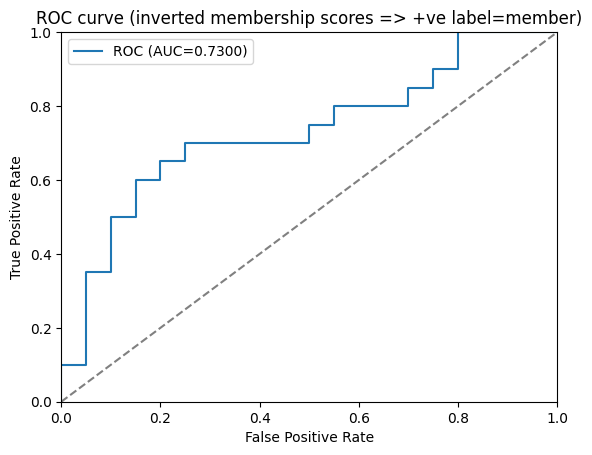

In [ ]:
# Cell 8: Minimal demonstration
# The difference is: we omit `split="train"` so we get a DatasetDict with a "train" key.

suite = "pythia"
size  = "70m"
dedup = False
#subset_name = "arxiv"
num_texts = 40
import zstandard

model_name = get_model_name(suite, size, dedup)
print(f"Loading model: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval().to(device)

from datasets import load_dataset

ds_streaming = load_dataset(
    "monology/pile-uncopyrighted",
    data_files={"train": ["train/00.jsonl.zst"]},  # just the first shard
    streaming=True,
)

ds_streaming["train"] = ds_streaming["train"].filter(
lambda ex: ex["meta"]["pile_set_name"] == "ArXiv"
)

texts = []
# We'll collect up to 'num_texts' lines from the stream
for i, example in enumerate(ds_streaming["train"]):
    if i >= num_texts:
        break
    texts.append(example["text"])

print(f"Collected {len(texts)} streamed lines from monology/pile-uncopyrighted shard 00.jsonl.zst")

# We'll define half as members, half as nonmembers
half = len(texts)//2
member_texts   = texts[:half]
nonmember_texts= texts[half:]

print(f"Member set size={len(member_texts)}, Non-member set size={len(nonmember_texts)}")

# Edgington approach
ref_dict = edgington_fit(nonmember_texts, model, tokenizer, device)
mem_scores_edg=[]
for txt in member_texts:
    s = edgington_score(txt, model, tokenizer, device, ref_dict)
    mem_scores_edg.append(s)
nm_scores_edg=[]
for txt in nonmember_texts:
    s = edgington_score(txt, model, tokenizer, device, ref_dict)
    nm_scores_edg.append(s)

print("Edgington Attack results:")
compute_metrics_and_show(np.array(mem_scores_edg), np.array(nm_scores_edg))

# Logistic approach
clf, all_keys, group2pca, group_tags = logistic_fit(member_texts, nonmember_texts, model, tokenizer, device)
mem_scores_log=[]
for txt in member_texts:
    sc = logistic_score(txt, model, tokenizer, device, clf, all_keys, group2pca, group_tags)
    mem_scores_log.append(sc)
nm_scores_log=[]
for txt in nonmember_texts:
    sc = logistic_score(txt, model, tokenizer, device, clf, all_keys, group2pca, group_tags)
    nm_scores_log.append(sc)

print("Logistic+PCA Attack results:")
compute_metrics_and_show(np.array(mem_scores_log), np.array(nm_scores_log))

print("Done.")